In [1]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [23]:
import yfinance as yf
df = yf.download('INFY.NS', start = '2020-01-01' , end = '2025-12-31')
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,INFY.NS,INFY.NS,INFY.NS,INFY.NS,INFY.NS
Date,,,,,
2020-01-01,619.740356,622.389739,616.123778,618.184403,2112415
2020-01-02,617.931885,623.062373,614.735841,621.464376,5658200
2020-01-03,627.436096,629.118230,617.259204,617.259204,7882938
2020-01-06,621.422424,633.996388,619.445937,627.520161,6519403
2020-01-07,612.212708,624.576352,609.857679,620.707464,7899363


In [24]:
#understand the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1486 entries, 2020-01-01 to 2025-12-30
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, INFY.NS)   1486 non-null   float64
 1   (High, INFY.NS)    1486 non-null   float64
 2   (Low, INFY.NS)     1486 non-null   float64
 3   (Open, INFY.NS)    1486 non-null   float64
 4   (Volume, INFY.NS)  1486 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 69.7 KB


In [25]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,INFY.NS,INFY.NS,INFY.NS,INFY.NS,INFY.NS
count,1486.000000,1486.000000,1486.000000,1486.000000,1.486000e+03
mean,1315.583206,1328.371435,1302.747536,1315.676344,7.554138e+06
std,317.278098,319.231753,315.060981,317.491956,4.968788e+06
min,442.779785,469.315536,428.313507,428.313507,0.000000e+00
25%,1181.334259,1188.656774,1170.667165,1178.705649,4.769261e+06
50%,1365.581482,1376.286343,1353.015961,1367.296243,6.452694e+06
75%,1513.421539,1528.781030,1496.416149,1512.206089,8.786073e+06
max,1901.082886,1907.500003,1880.072854,1897.042542,9.043211e+07


In [26]:
df.isnull().sum()

Price   Ticker 
Close   INFY.NS    0
High    INFY.NS    0
Low     INFY.NS    0
Open    INFY.NS    0
Volume  INFY.NS    0
dtype: int64

In [27]:
df.columns

MultiIndex([( 'Close', 'INFY.NS'),
            (  'High', 'INFY.NS'),
            (   'Low', 'INFY.NS'),
            (  'Open', 'INFY.NS'),
            ('Volume', 'INFY.NS')],
           names=['Price', 'Ticker'])

In [28]:
df.columns = df.columns.get_level_values(0)
df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-01,619.740356,622.389739,616.123778,618.184403,2112415
2020-01-02,617.931885,623.062373,614.735841,621.464376,5658200
2020-01-03,627.436096,629.118230,617.259204,617.259204,7882938
2020-01-06,621.422424,633.996388,619.445937,627.520161,6519403
2020-01-07,612.212708,624.576352,609.857679,620.707464,7899363


In [29]:
print(df.columns) 
print(df.columns.name)

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')
Price


In [30]:
df.columns.name = None
df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2020-01-01,619.740356,622.389739,616.123778,618.184403,2112415
2020-01-02,617.931885,623.062373,614.735841,621.464376,5658200
2020-01-03,627.436096,629.118230,617.259204,617.259204,7882938
2020-01-06,621.422424,633.996388,619.445937,627.520161,6519403
2020-01-07,612.212708,624.576352,609.857679,620.707464,7899363


In [31]:
df['Prev_Close'] = df['Close'].shift(1)

In [35]:
df['Daily_Return'] = (
    (df['Close'] - df['Prev_Close'])/
    df['Prev_Close']
)*100 

df['MA20'] = df['Close'].rolling(20).mean()

df['MA50'] = df['Close'].rolling(50).mean()

df[['Close','MA20','MA50']].head(60)
    
    
    

,Close,MA20,MA50
Date,,,
2020-01-01,619.740356,NaN,NaN
2020-01-02,617.931885,NaN,NaN
2020-01-03,627.436096,NaN,NaN
2020-01-06,621.422424,NaN,NaN
2020-01-07,612.212708,NaN,NaN
2020-01-08,604.054382,NaN,NaN
2020-01-09,611.918396,NaN,NaN
2020-01-10,620.833740,NaN,NaN
2020-01-13,650.607422,NaN,NaN


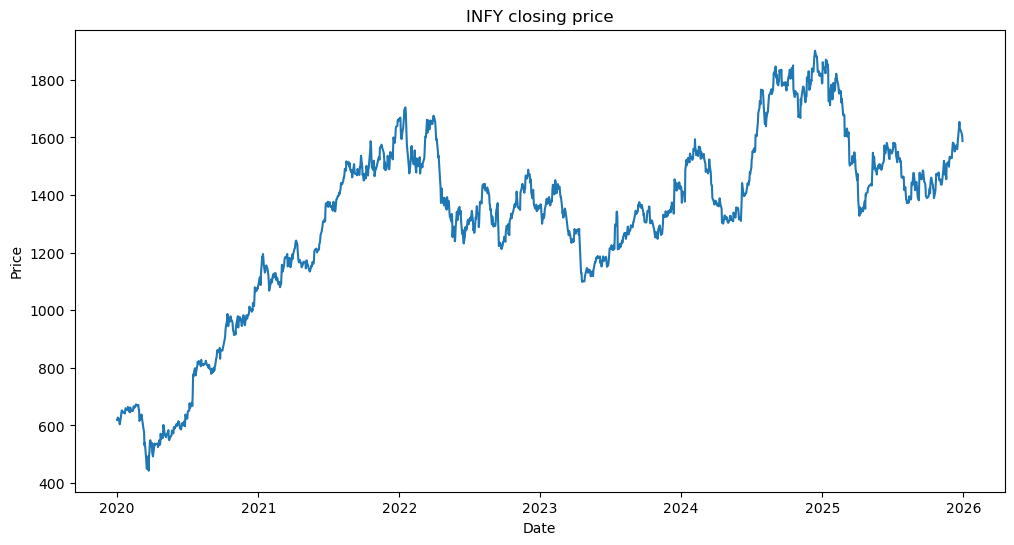

In [39]:
#Closing Price Trend
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df.index,df['Close'])
plt.title('INFY closing price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

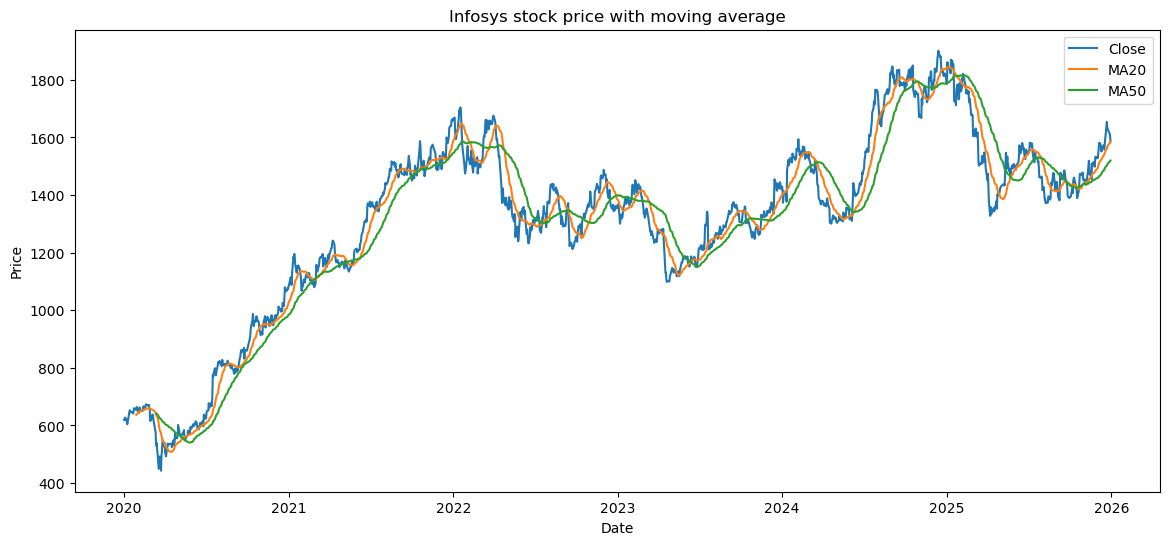

In [40]:
#Moving average chart
plt.figure(figsize=(14,6))
plt.plot(df.index,df['Close'],label='Close')
plt.plot(df.index,df['MA20'],label='MA20')
plt.plot(df.index,df['MA50'],label='MA50')
plt.title('Infosys stock price with moving average')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

In [42]:
#KPI analysis

print("Highest close price:",df['Close'].max())

print("Lowest close price:",df['Close'].min())

print("Average close price:",df['Close'].mean())

Highest close price: 1901.0828857421875
Lowest close price: 442.77978515625
Average close price: 1315.5832056428028


In [44]:
print("Highest volume:",df['Volume'].max())

print("Average volume:",df['Volume'].mean())

Highest volume: 90432109
Average volume: 7554137.515477792


In [45]:
#Best and Worst trading days

print("Best day return:",
      df['Daily_Return'].max())

print("Worst day return:",
      df['Daily_Return'].min())

Best day return: 12.033427785000876
Worst day return: -10.03929648028089


In [48]:
print("Highest price date: ",
      df['Close'].idxmax())
print("Lowest price date:",
      df['Close'].idxmin())
print("Highest return day date:",
      df['Daily_Return'].idxmax())
print("Lowest return day date:",
      df['Daily_Return'].idxmin())

Highest price date:  2024-12-13 00:00:00
Lowest price date: 2020-03-23 00:00:00
Highest return day date: 2020-03-24 00:00:00
Lowest return day date: 2020-03-23 00:00:00


In [52]:
monthly_close = df['Close'].resample('ME').last()
monthly_return = monthly_close.pct_change()*100
monthly_return.head()

Date
2020-01-31          NaN
2020-02-29    -5.702678
2020-03-31   -12.327466
2020-04-30    11.535472
2020-05-31    -2.109553
Freq: ME, Name: Close, dtype: float64

In [55]:
monthly_return.sort_values(ascending=False).head(10)

Date
2020-07-31    31.258927
2024-07-31    19.243661
2020-12-31    14.163642
2021-06-30    13.420627
2020-04-30    11.535472
2024-06-30    11.361857
2022-03-31    11.147710
2021-12-31    10.223923
2022-10-31     9.975908
2021-03-31     9.155813
Name: Close, dtype: float64

In [56]:
monthly_return.sort_values().head(10)

Date
2022-04-30   -17.793731
2020-03-31   -12.327466
2023-04-30   -12.269337
2024-03-31   -10.505397
2025-02-28   -10.219181
2022-01-31    -8.028088
2022-12-31    -7.752531
2025-03-31    -6.935468
2025-07-31    -5.793477
2020-02-29    -5.702678
Name: Close, dtype: float64

In [57]:
daily_volatility = df['Daily_Return'].std()

print('Daily volatility:',daily_volatility)

Daily volatility: 1.7268749099048413


In [58]:
df.to_csv("Infosys_Stock_Analysis.csv")